# Сравнение двух моделей прогноза электропотребления

**Универсальная модель `allday`** против **каскада специалистов `workday` + `nonworkday`**.

Ноутбук загружает обученные LightGBM-модели из `artefakts/`, строит почасовой прогноз на заданном окне, считает метрики (MAPE, WAPE, R²) и рисует подневные графики «факт против прогноза» для обеих моделей.

Стиль и структура повторяют утилиты ветки `GBM` (`AnalysisYear.py`, `ChartByDay.py`, `project_tree.py`):

- блок настройки путей и дерева проекта;
- загрузка данных и моделей с понятными сообщениями об отсутствии файлов;
- инкапсуляция логики в статические методы класса;
- демо-режим (синтетические данные/модели), если артефактов нет, — чтобы ноутбук был самодостаточным и читался без запуска.

> ⚠️ Ноутбук **не запускался** при подготовке. Перед первым запуском убедитесь, что обучены модели (`project/src/avto_test_py/...`) и присутствует датасет `project/data/dataset.xlsx`.

## 1. Импорты и глобальные настройки

Импорты сгруппированы: стандартная библиотека, научный стек, опциональные зависимости. Настройки matplotlib (DPI, шрифт) применяются сразу при импорте — как в `ChartByDay`.

In [1]:
import os
import sys
import json
import pickle
import warnings
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Метрики берём из sklearn, если он установлен; иначе используем собственную реализацию ниже.
try:
    from sklearn.metrics import r2_score as _sk_r2_score
    _HAS_SKLEARN = True
except Exception:
    _HAS_SKLEARN = False

# Глобальные настройки графиков (как в ChartByDay).
plt.rcParams['figure.dpi'] = 120
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.size'] = 10

warnings.filterwarnings('ignore')
print('✅ Импорты выполнены. sklearn доступен:', _HAS_SKLEARN)

✅ Импорты выполнены. sklearn доступен: True


## 2. Пути проекта и дерево каталогов

Все пути вычисляются относительно расположения ноутбука (`project/notebooks/`) — без хардкода абсолютных путей. Если ноутбук запущен из другого рабочего каталога, корень определяется поиском вверх по дереву до папки `project`.

Функция `print_tree` перенесена из `GBM/utils/project_tree.py` (с теми же иконками и игнор-листом).

In [2]:
def find_project_root(marker_dirs=('project', '.git')):
    """Ищет корень проекта вверх по дереву от текущего каталога/ноутбука."""
    try:
        here = Path(__file__).resolve().parent  # при импорте как .py
    except NameError:
        here = Path.cwd().resolve()             # обычный случай в Jupyter

    for candidate in [here, *here.parents]:
        if (candidate / 'project').is_dir():
            return candidate
        if candidate.name == 'project':
            return candidate.parent
    # Фолбэк: два уровня вверх от notebooks/ -> project/ -> ROOT
    return here.parent.parent


ROOT_DIR = find_project_root()
PROJ_DIR = ROOT_DIR / 'project'
DATA_DIR = PROJ_DIR / 'data'
CONFIG_PATH = PROJ_DIR / 'configs' / 's_config.json'

print(f'📦 Корень проекта : {ROOT_DIR}')
print(f'📁 project/       : {PROJ_DIR}')
print(f'📁 data/          : {DATA_DIR}')
print(f'⚙️  config         : {CONFIG_PATH}')

📦 Корень проекта : C:\Users\Дмитрий\PycharmProjects\regression_modeling
📁 project/       : C:\Users\Дмитрий\PycharmProjects\regression_modeling\project
📁 data/          : C:\Users\Дмитрий\PycharmProjects\regression_modeling\project\data
⚙️  config         : C:\Users\Дмитрий\PycharmProjects\regression_modeling\project\configs\s_config.json


In [3]:
# --- print_tree из GBM/utils/project_tree.py (без изменений логики) ---
_IGNORE = {
    '.git', '__pycache__', '.venv', 'venv', 'env',
    'node_modules', '.idea', '.vscode', '.mypy_cache',
    '.pytest_cache', 'dist', 'build', '.eggs',
}


def print_tree(directory, prefix='', ignore=None, max_depth=2, current_depth=0):
    if ignore is None:
        ignore = _IGNORE
    if max_depth is not None and current_depth > max_depth:
        return
    directory = Path(directory)
    try:
        entries = sorted(directory.iterdir(), key=lambda e: (e.is_file(), e.name.lower()))
    except (PermissionError, FileNotFoundError):
        print(prefix + '  [Нет доступа]')
        return
    entries = [e for e in entries if e.name not in ignore and not e.name.endswith('.egg-info')]
    for i, entry in enumerate(entries):
        is_last = i == len(entries) - 1
        connector = '└── ' if is_last else '├── '
        icon = '📁 ' if entry.is_dir() else '📄 '
        print(prefix + connector + icon + entry.name)
        if entry.is_dir():
            extension = '    ' if is_last else '│   '
            print_tree(entry, prefix + extension, ignore, max_depth, current_depth + 1)


print(f'\n📦 Структура проекта (до 2 уровней): {PROJ_DIR}\n')
print_tree(PROJ_DIR, max_depth=2)


📦 Структура проекта (до 2 уровней): C:\Users\Дмитрий\PycharmProjects\regression_modeling\project

├── 📁 configs
│   ├── 📄 .env.example
│   └── 📄 s_config.json
├── 📁 data
│   ├── 📄 .gitkeep
│   ├── 📄 dataset.xlsx
│   └── 📄 dataset_no_intercept.xlsx
├── 📁 notebooks
│   ├── 📄 .gitkeep
│   └── 📄 two_models_comparison.ipynb
├── 📁 src
│   ├── 📁 avto_test_py
│   │   ├── 📄 .gitkeep
│   │   ├── 📄 __init__.py
│   │   ├── 📄 benchmark_device.py
│   │   ├── 📄 run_specialists_gpu.py
│   │   ├── 📄 tune_allday_gpu.py
│   │   ├── 📄 tune_nonworkday_gpu.py
│   │   └── 📄 tune_workday_gpu.py
│   ├── 📁 utils
│   │   └── 📄 .gitkeep
│   ├── 📁 web_interface
│   │   ├── 📁 static
│   │   ├── 📁 templates
│   │   ├── 📄 __init__.py
│   │   └── 📄 app.py
│   └── 📄 run_webui.py
├── 📁 tests
│   ├── 📄 .gitkeep
│   └── 📄 test-34.py
├── 📄 docker-compose.yml
├── 📄 Dockerfile
├── 📄 project_overview.md
├── 📄 README.md
├── 📄 report.md
├── 📄 requirements.txt
└── 📄 self-checklist.md


## 3. Конфигурация сравнения

Параметры читаются из `project/configs/s_config.json` (тот же файл, что используют скрипты обучения). Если конфиг недоступен — берутся разумные значения по умолчанию, чтобы ноутбук оставался работоспособным.

Здесь же задаются **пути к артефактам моделей**. Скрипты обучения сохраняют модели как `best_model_<specialist>.pkl` в папки вида `artefakts/results/<specialist>/`.

In [4]:
DEFAULT_CFG = {
    'data': {
        'dataset_path': 'project/data/dataset.xlsx',
        'date_col': 'dateByOurs',
        'target_col': 'Ypowerconsumption',
    },
    'forecast': {
        'forecast_start': '2022-01-01',
        'forecast_end': '2022-01-30',
    },
}


def load_config(path=CONFIG_PATH):
    """Читает s_config.json; при отсутствии возвращает значения по умолчанию."""
    path = Path(path)
    if not path.exists():
        print(f'⚠️  Конфиг не найден: {path}. Использую значения по умолчанию.')
        return DEFAULT_CFG
    with open(path, encoding='utf-8') as f:
        cfg = json.load(f)
    print(f'✅ Конфиг загружен: {path}')
    return cfg


CFG = load_config()

DATE_COL = CFG.get('data', {}).get('date_col', 'dateByOurs')
TARGET_COL = CFG.get('data', {}).get('target_col', 'Ypowerconsumption')
DATASET_PATH = ROOT_DIR / CFG.get('data', {}).get('dataset_path', 'project/data/dataset.xlsx')

_fc = CFG.get('forecast', {})
FORECAST_START = pd.Timestamp(_fc.get('forecast_start', '2022-01-01'))
FORECAST_END = pd.Timestamp(_fc.get('forecast_end', '2022-01-30'))
TRAIN_DAYS = int(CFG.get('model', {}).get('train_days', 90))

# Где скрипты обучения сохраняют .pkl-модели. Путь к специалистам выводим
# из output_dir универсальной модели, заменяя последний сегмент на имя специалиста.
_allday_out = CFG.get('tune', {}).get('output_dir', 'artefakts/results/allday')
_results_root = (ROOT_DIR / _allday_out).parent

MODEL_PATHS = {
    'allday': ROOT_DIR / _allday_out / 'best_model_allday.pkl',
    'workday': _results_root / 'workday' / 'best_model_workday.pkl',
    'nonworkday': _results_root / 'nonworkday' / 'best_model_nonworkday.pkl',
}

print('Колонка даты      :', DATE_COL)
print('Целевая переменная:', TARGET_COL)
print('Датасет           :', DATASET_PATH)
print(f'Окно прогноза     : {FORECAST_START.date()} — {FORECAST_END.date()}')
print(f'Дней на обучение  : {TRAIN_DAYS}')
print('\nОжидаемые пути к моделям:')
for name, p in MODEL_PATHS.items():
    mark = '✅' if p.exists() else '❌'
    print(f'  {mark} {name:11s} -> {p}')

✅ Конфиг загружен: C:\Users\Дмитрий\PycharmProjects\regression_modeling\project\configs\s_config.json
Колонка даты      : dateByOurs
Целевая переменная: Ypowerconsumption
Датасет           : C:\Users\Дмитрий\PycharmProjects\regression_modeling\project\data\dataset.xlsx
Окно прогноза     : 2022-01-01 — 2022-01-30
Дней на обучение  : 90

Ожидаемые пути к моделям:
  ❌ allday      -> C:\Users\Дмитрий\PycharmProjects\regression_modeling\artefakts\results\allday\best_model_allday.pkl
  ❌ workday     -> C:\Users\Дмитрий\PycharmProjects\regression_modeling\artefakts\results\workday\best_model_workday.pkl
  ❌ nonworkday  -> C:\Users\Дмитрий\PycharmProjects\regression_modeling\artefakts\results\nonworkday\best_model_nonworkday.pkl


## 4. Класс `ModelComparison`

По образцу `ChartByDay`: вся логика собрана в статических методах одного класса. Это делает ноутбук читаемым и переносимым (методы можно скопировать в `utils/`).

Группы методов:

1. **Загрузка**: `load_and_parse_data`, `load_model`.
2. **Признаки**: `build_features` — точная копия feature-engineering из `tune_*_gpu.py`, чтобы прогноз совпадал с обучением.
3. **Прогноз**: `predict_allday`, `predict_specialists` (каскад по флагу `workday`).
4. **Метрики**: `mape`, `wape`, `r2`, `evaluate`.
5. **Графики**: `plot_forecast_by_day`, `plot_metrics_bar`.

In [5]:
FEATURE_LAGS = [24, 48, 168, 336]

BASE_FEATURES = [
    'hour_sin', 'hour_cos', 'hour_sin_2', 'hour_cos_2',
    'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'doy_sin', 'doy_cos',
    'workday', 'is_weekend', 'is_monday', 'is_friday',
    'temp', 'temp_squared',
    'lag_24', 'lag_48', 'lag_168', 'lag_336',
    'roll_mean_24', 'roll_std_24', 'roll_mean_168',
    'workday_hour_sin', 'workday_hour_cos', 'lag_mean_same_type',
]
OPTIONAL_FEATURES = ['wet', 'cloud', 'windspeed', 'daylength', 'day/night']

In [6]:
class ModelComparison:
    """Сравнивает универсальную модель allday с каскадом workday+nonworkday."""

    # ------------------------------------------------------------------
    # Загрузка
    # ------------------------------------------------------------------
    @staticmethod
    def load_and_parse_data(filepath):
        """Загружает датасет из .xlsx/.csv (автоопределение по расширению)."""
        filepath = str(filepath)
        if filepath.endswith(('.xlsx', '.xls')):
            df = pd.read_excel(filepath)
        elif filepath.endswith('.csv'):
            df = None
            for enc in ('utf-8', 'cp1251', 'latin1'):
                try:
                    df = pd.read_csv(filepath, decimal=',', encoding=enc)
                    break
                except UnicodeDecodeError:
                    continue
            if df is None:
                raise ValueError('Не удалось прочитать CSV ни в одной из кодировок')
        else:
            raise ValueError('Неподдерживаемый формат файла. Используйте .csv или .xlsx')

        if DATE_COL not in df.columns:
            raise ValueError(f"В данных нет колонки даты '{DATE_COL}'")
        df[DATE_COL] = pd.to_datetime(df[DATE_COL])
        df = df.sort_values(DATE_COL).reset_index(drop=True)

        if 'workday' not in df.columns:
            df['workday'] = (df[DATE_COL].dt.dayofweek < 5).astype(int)
            print("ℹ️  Колонка 'workday' отсутствовала — рассчитана из дня недели.")
        return df

    @staticmethod
    def load_model(path):
        """Загружает pickle-модель {'model','features',...}. None, если файла нет."""
        path = Path(path)
        if not path.exists():
            print(f'❌ Модель не найдена: {path}')
            return None
        with open(path, 'rb') as f:
            bundle = pickle.load(f)
        print(f"✅ Модель загружена: {path.name} "
              f"(признаков: {len(bundle.get('features', []))})")
        return bundle

    # ------------------------------------------------------------------
    # Признаки (копия логики из tune_*_gpu.py)
    # ------------------------------------------------------------------
    @staticmethod
    def build_features(df):
        """Строит те же признаки, что и скрипты обучения LightGBM."""
        df = df.copy()
        df['hour'] = df[DATE_COL].dt.hour
        df['dayofweek'] = df[DATE_COL].dt.dayofweek
        df['month'] = df[DATE_COL].dt.month
        df['doy'] = df[DATE_COL].dt.dayofyear

        df['is_weekend'] = (df['dayofweek'] >= 5).astype(int)
        df['is_monday'] = (df['dayofweek'] == 0).astype(int)
        df['is_friday'] = (df['dayofweek'] == 4).astype(int)

        df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
        df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
        df['hour_sin_2'] = np.sin(4 * np.pi * df['hour'] / 24)
        df['hour_cos_2'] = np.cos(4 * np.pi * df['hour'] / 24)
        df['dow_sin'] = np.sin(2 * np.pi * df['dayofweek'] / 7)
        df['dow_cos'] = np.cos(2 * np.pi * df['dayofweek'] / 7)
        df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
        df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
        df['doy_sin'] = np.sin(2 * np.pi * df['doy'] / 365)
        df['doy_cos'] = np.cos(2 * np.pi * df['doy'] / 365)

        if 'temp' in df.columns:
            df['temp_squared'] = df['temp'] ** 2
        else:
            df['temp'] = 0.0
            df['temp_squared'] = 0.0

        for lag in FEATURE_LAGS:
            df[f'lag_{lag}'] = df[TARGET_COL].shift(lag)
        df['roll_mean_24'] = df[TARGET_COL].shift(24).rolling(24).mean()
        df['roll_std_24'] = df[TARGET_COL].shift(24).rolling(24).std()
        df['roll_mean_168'] = df[TARGET_COL].shift(24).rolling(168).mean()

        df['workday_hour_sin'] = df['workday'] * df['hour_sin']
        df['workday_hour_cos'] = df['workday'] * df['hour_cos']
        df['lag_mean_same_type'] = (
            df.groupby(['workday', 'hour'])[TARGET_COL]
              .transform(lambda x: x.shift(1).rolling(4, min_periods=1).mean())
        )
        return df

    @staticmethod
    def resolve_features(bundle, df):
        """Список признаков модели, оставляя только присутствующие в df."""
        feats = list(bundle.get('features', BASE_FEATURES)) if bundle else BASE_FEATURES
        return [c for c in feats if c in df.columns]

    # ------------------------------------------------------------------
    # Прогноз
    # ------------------------------------------------------------------
    @staticmethod
    def predict_allday(bundle, df):
        """Прогноз универсальной модели по всем строкам df."""
        feats = ModelComparison.resolve_features(bundle, df)
        return np.asarray(bundle['model'].predict(df[feats]))

    @staticmethod
    def predict_specialists(bundle_work, bundle_nonwork, df):
        """Каскад: workday-модель на рабочих днях, nonworkday — на остальных."""
        preds = np.full(len(df), np.nan)
        mask_work = df['workday'].values == 1
        if bundle_work is not None and mask_work.any():
            feats = ModelComparison.resolve_features(bundle_work, df)
            preds[mask_work] = bundle_work['model'].predict(df.loc[mask_work, feats])
        if bundle_nonwork is not None and (~mask_work).any():
            feats = ModelComparison.resolve_features(bundle_nonwork, df)
            preds[~mask_work] = bundle_nonwork['model'].predict(df.loc[~mask_work, feats])
        return preds

    # ------------------------------------------------------------------
    # Метрики
    # ------------------------------------------------------------------
    @staticmethod
    def mape(y_true, y_pred):
        y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
        mask = y_true != 0
        if not mask.any():
            return float('nan')
        return float(np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100)

    @staticmethod
    def wape(y_true, y_pred):
        y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
        denom = np.sum(np.abs(y_true))
        if denom == 0:
            return float('nan')
        return float(np.sum(np.abs(y_true - y_pred)) / denom * 100)

    @staticmethod
    def r2(y_true, y_pred):
        if _HAS_SKLEARN:
            return float(_sk_r2_score(y_true, y_pred))
        y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
        ss_res = np.sum((y_true - y_pred) ** 2)
        ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
        return float('nan') if ss_tot == 0 else float(1 - ss_res / ss_tot)

    @staticmethod
    def evaluate(y_true, y_pred):
        """Считает MAPE/WAPE/R² по строкам без NaN."""
        y_true = np.asarray(y_true, dtype=float)
        y_pred = np.asarray(y_pred, dtype=float)
        valid = ~(np.isnan(y_true) | np.isnan(y_pred))
        y_true, y_pred = y_true[valid], y_pred[valid]
        return {
            'MAPE': ModelComparison.mape(y_true, y_pred),
            'WAPE': ModelComparison.wape(y_true, y_pred),
            'R2': ModelComparison.r2(y_true, y_pred),
            'n': int(valid.sum()),
        }

    # ------------------------------------------------------------------
    # Графики
    # ------------------------------------------------------------------
    @staticmethod
    def plot_forecast_by_day(dates, y_true, preds_dict, title=None,
                             filename=None, figsize_width=22):
        """Линейный график факт/прогноз по часам с датами на оси X."""
        dates = pd.to_datetime(pd.Series(dates)).reset_index(drop=True)
        fig, ax = plt.subplots(figsize=(figsize_width, 6))
        ax.plot(dates, y_true, color='black', linewidth=1.2,
                label='Факт', zorder=5)
        colors = {'allday': 'steelblue', 'specialists': 'darkorange'}
        for name, y_pred in preds_dict.items():
            ax.plot(dates, y_pred, linewidth=1.0, alpha=0.85,
                    color=colors.get(name), label=name)

        ax.set_xlabel('Дата', fontsize=11)
        ax.set_ylabel('Потребление (МВт)', fontsize=11)
        ax.set_title(title or 'Факт против прогноза (почасовой)',
                     fontsize=14, pad=20)
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
        ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
        ax.grid(True, linestyle='--', alpha=0.5)
        ax.legend(loc='best', fontsize=9)
        plt.tight_layout()
        if filename:
            os.makedirs(os.path.dirname(filename) or '.', exist_ok=True)
            plt.savefig(filename, format='png', dpi=300,
                        bbox_inches='tight', facecolor='white')
            print(f'✅ График сохранён: {filename}')
        plt.show()
        return fig, ax

    @staticmethod
    def plot_metrics_bar(metrics_table, filename=None):
        """Столбчатое сравнение MAPE/WAPE/R² по моделям."""
        metric_names = ['MAPE', 'WAPE', 'R2']
        models = list(metrics_table.keys())
        x = np.arange(len(metric_names))
        width = 0.8 / max(len(models), 1)
        fig, ax = plt.subplots(figsize=(9, 5))
        for i, model in enumerate(models):
            vals = [metrics_table[model].get(m, np.nan) for m in metric_names]
            bars = ax.bar(x + i * width, vals, width, label=model)
            ax.bar_label(bars, fmt='%.2f', fontsize=8, padding=2)
        ax.set_xticks(x + width * (len(models) - 1) / 2)
        ax.set_xticklabels(metric_names)
        ax.set_ylabel('Значение')
        ax.set_title('Сравнение метрик: allday vs специалисты', fontsize=13)
        ax.legend()
        ax.grid(True, axis='y', linestyle='--', alpha=0.4)
        plt.tight_layout()
        if filename:
            os.makedirs(os.path.dirname(filename) or '.', exist_ok=True)
            plt.savefig(filename, dpi=300, bbox_inches='tight', facecolor='white')
            print(f'✅ График сохранён: {filename}')
        plt.show()
        return fig, ax


print('✅ Класс ModelComparison определён.')

✅ Класс ModelComparison определён.


## 5. Загрузка данных

Читаем датасет. Если файл отсутствует — генерируем демонстрационный почасовой ряд (тренд + суточная/годовая сезонность + шум), как делает `AnalysisYear.py`. Это позволяет проверить логику ноутбука даже без приватных корпоративных данных.

In [7]:
def make_demo_dataframe(start='2019-01-01', periods=24 * 365 * 4):
    """Синтетический почасовой ряд для демонстрации (нет реальных данных)."""
    dates = pd.date_range(start, periods=periods, freq='h')
    idx = np.arange(periods)
    trend = np.linspace(180, 200, periods)
    daily = 30 * np.sin(2 * np.pi * dates.hour / 24)
    yearly = 20 * np.sin(2 * np.pi * idx / (24 * 365))
    workday = (dates.dayofweek < 5).astype(int)
    noise = np.random.RandomState(42).normal(0, 8, periods)
    target = trend + daily + yearly + 10 * workday + noise
    return pd.DataFrame({
        DATE_COL: dates,
        TARGET_COL: target,
        'temp': 10 + 12 * np.sin(2 * np.pi * idx / (24 * 365)) + noise / 4,
        'workday': workday,
    })


USING_DEMO_DATA = False
try:
    df = ModelComparison.load_and_parse_data(DATASET_PATH)
    print(f'📊 Загружено записей: {len(df)}')
    print(f'📅 Период: {df[DATE_COL].min()} — {df[DATE_COL].max()}')
except FileNotFoundError:
    print(f'❌ Файл {DATASET_PATH} не найден — генерирую демо-данные.')
    df = make_demo_dataframe()
    USING_DEMO_DATA = True
    print(f'🧪 Демо-данные: {len(df)} строк, '
          f'{df[DATE_COL].min().date()} — {df[DATE_COL].max().date()}')

df.head()

📊 Загружено записей: 31390
📅 Период: 2019-01-01 00:00:00 — 2022-07-31 21:00:00


,Unnamed: 0,dateByOurs,sunrise,sunset,const,hour,temp,cloud,wet,winddir,windspeed,daylength,day/night,workday,Ypowerconsumption
0,0,2019-01-01 00:00:00,07:32:00,16:36:00,1,1.0,-2.700000,1,89.000000,5,1.000000,9.066667,0,0.0,215.191
1,1,2019-01-01 01:00:00,07:32:00,16:36:00,1,2.0,-2.733333,1,88.333333,5,1.000000,9.066667,0,0.0,202.239
2,2,2019-01-01 02:00:00,07:32:00,16:36:00,1,3.0,-2.766667,1,87.666667,5,1.000000,9.066667,0,0.0,188.462
3,3,2019-01-01 03:00:00,07:32:00,16:36:00,1,4.0,-2.800000,1,87.000000,5,1.000000,9.066667,0,0.0,179.276
4,4,2019-01-01 04:00:00,07:32:00,16:36:00,1,5.0,-2.733333,1,87.000000,5,0.666667,9.066667,0,0.0,173.035


## 6. Загрузка моделей

Загружаем три модели: универсальную `allday` и пару специалистов `workday`/`nonworkday`. Отсутствующие модели не прерывают работу — выводится понятное сообщение, а недостающие модели будут обучены «на лету» в демо-режиме (см. следующую ячейку).

In [8]:
bundle_allday = ModelComparison.load_model(MODEL_PATHS['allday'])
bundle_workday = ModelComparison.load_model(MODEL_PATHS['workday'])
bundle_nonworkday = ModelComparison.load_model(MODEL_PATHS['nonworkday'])

models_present = all(b is not None for b in
                     (bundle_allday, bundle_workday, bundle_nonworkday))
print('\nВсе модели на месте:' , models_present)

❌ Модель не найдена: C:\Users\Дмитрий\PycharmProjects\regression_modeling\artefakts\results\allday\best_model_allday.pkl
❌ Модель не найдена: C:\Users\Дмитрий\PycharmProjects\regression_modeling\artefakts\results\workday\best_model_workday.pkl
❌ Модель не найдена: C:\Users\Дмитрий\PycharmProjects\regression_modeling\artefakts\results\nonworkday\best_model_nonworkday.pkl

Все модели на месте: False


## 7. Подготовка прогнозного окна

Строим признаки на всём ряду, затем берём окно `[forecast_start, forecast_end]`. Лаги (24…336 ч) и скользящие средние требуют истории, поэтому признаки считаются до фильтрации по датам.

Если обученных моделей нет (демо-режим), обучаем лёгкие LightGBM/фолбэк-модели на данных **до** начала прогнозного окна, чтобы получить честное сравнение без подглядывания в будущее.

In [9]:
feat_df = ModelComparison.build_features(df)
feat_df = feat_df.dropna(subset=[c for c in BASE_FEATURES if c in feat_df.columns]
                         ).reset_index(drop=True)

train_mask = feat_df[DATE_COL] < FORECAST_START
fcast_mask = (feat_df[DATE_COL] >= FORECAST_START) & (feat_df[DATE_COL] <= FORECAST_END)
df_train = feat_df[train_mask].reset_index(drop=True)
df_fcast = feat_df[fcast_mask].reset_index(drop=True)

print(f'Обучающих строк : {len(df_train)}')
print(f'Строк в прогнозе: {len(df_fcast)} '
      f'({FORECAST_START.date()} — {FORECAST_END.date()})')
if df_fcast.empty:
    raise RuntimeError('Прогнозное окно пустое — проверьте forecast_start/forecast_end.')

Обучающих строк : 25968
Строк в прогнозе: 697 (2022-01-01 — 2022-01-30)


In [10]:
def train_fallback_model(df_tr, features, workday_flag=None):
    """Обучает быструю модель для демо-режима (LightGBM или GBR из sklearn)."""
    data = df_tr if workday_flag is None else df_tr[df_tr['workday'] == workday_flag]
    feats = [c for c in features if c in data.columns]
    X, y = data[feats], data[TARGET_COL].values
    try:
        from lightgbm import LGBMRegressor
        model = LGBMRegressor(n_estimators=200, learning_rate=0.05,
                              num_leaves=64, verbosity=-1, random_state=42)
    except Exception:
        from sklearn.ensemble import GradientBoostingRegressor
        model = GradientBoostingRegressor(random_state=42)
    model.fit(X, y)
    return {'model': model, 'features': feats, 'specialist': 'demo'}


if bundle_allday is None:
    print('🧪 Обучаю демо-модель allday...')
    bundle_allday = train_fallback_model(df_train, BASE_FEATURES)
if bundle_workday is None:
    print('🧪 Обучаю демо-модель workday...')
    bundle_workday = train_fallback_model(df_train, BASE_FEATURES, workday_flag=1)
if bundle_nonworkday is None:
    print('🧪 Обучаю демо-модель nonworkday...')
    bundle_nonworkday = train_fallback_model(df_train, BASE_FEATURES, workday_flag=0)

print('✅ Модели готовы к прогнозу.')

🧪 Обучаю демо-модель allday...
🧪 Обучаю демо-модель workday...
🧪 Обучаю демо-модель nonworkday...
✅ Модели готовы к прогнозу.


## 8. Прогноз обеих моделей

Получаем почасовой прогноз на окне:

- **allday** — одна модель на все дни;
- **specialists** — каскад: `workday`-модель для рабочих дней, `nonworkday` — для выходных/праздничных.

In [11]:
y_true = df_fcast[TARGET_COL].values
pred_allday = ModelComparison.predict_allday(bundle_allday, df_fcast)
pred_specialists = ModelComparison.predict_specialists(
    bundle_workday, bundle_nonworkday, df_fcast)

result_df = pd.DataFrame({
    DATE_COL: df_fcast[DATE_COL].values,
    'workday': df_fcast['workday'].values,
    'y_true': y_true,
    'pred_allday': pred_allday,
    'pred_specialists': pred_specialists,
})
result_df.head()

,dateByOurs,workday,y_true,pred_allday,pred_specialists
0,2022-01-01 00:00:00,0.0,214.510,205.991960,202.907124
1,2022-01-01 01:00:00,0.0,204.494,195.264917,199.772488
2,2022-01-01 02:00:00,0.0,193.323,183.581197,192.282599
3,2022-01-01 03:00:00,0.0,184.104,177.009716,187.148439
4,2022-01-01 04:00:00,0.0,179.708,176.819703,185.588349


## 9. Метрики и сравнение

Считаем MAPE, WAPE, R² для каждой модели (метрики из `project_overview.md`). Выводим таблицу и строим столбчатое сравнение.

In [12]:
metrics_table = {
    'allday': ModelComparison.evaluate(y_true, pred_allday),
    'specialists': ModelComparison.evaluate(y_true, pred_specialists),
}
metrics_df = pd.DataFrame(metrics_table).T[['MAPE', 'WAPE', 'R2', 'n']]
print('Сравнение метрик на окне '
      f'{FORECAST_START.date()} — {FORECAST_END.date()}'
      + ('  (ДЕМО-ДАННЫЕ)' if USING_DEMO_DATA else ''))
metrics_df.round(3)

Сравнение метрик на окне 2022-01-01 — 2022-01-30


,MAPE,WAPE,R2,n
allday,1.980,1.990,0.961,697.0
specialists,2.086,2.091,0.962,697.0


🏆 Лучший MAPE: allday (1.98%)
🏆 Лучший R²  : specialists (0.962)


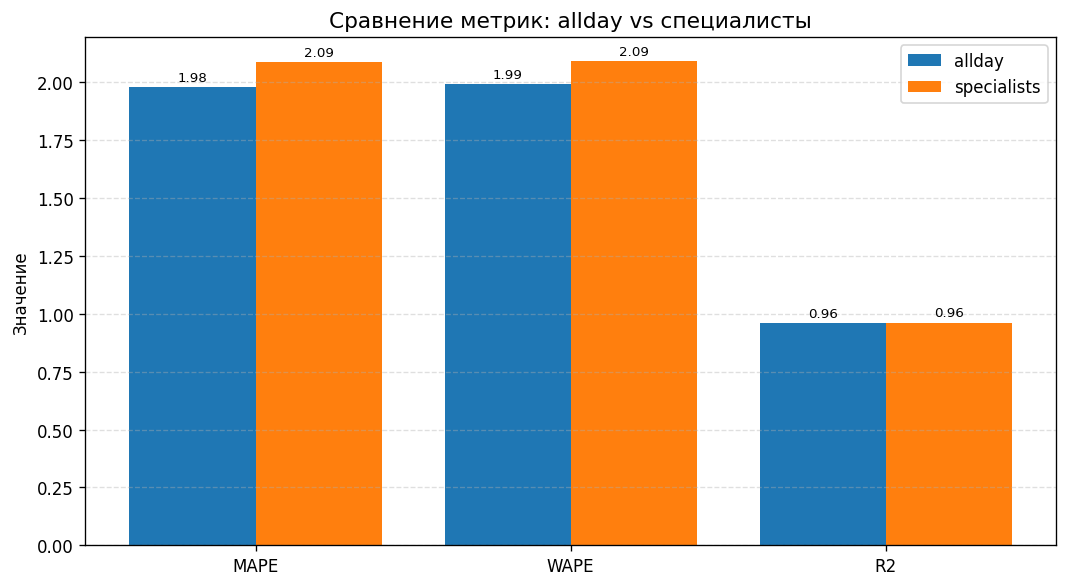

(<Figure size 1080x600 with 1 Axes>,
 <Axes: title={'center': 'Сравнение метрик: allday vs специалисты'}, ylabel='Значение'>)

In [13]:
best_mape = metrics_df['MAPE'].idxmin()
best_r2 = metrics_df['R2'].idxmax()
print(f'🏆 Лучший MAPE: {best_mape} ({metrics_df.loc[best_mape, "MAPE"]:.2f}%)')
print(f'🏆 Лучший R²  : {best_r2} ({metrics_df.loc[best_r2, "R2"]:.3f})')

ModelComparison.plot_metrics_bar(metrics_table)

## 10. Подневные графики «факт против прогноза»

По образцу `ChartByDay`/`AnalysisYear`: строим линейный график на всё окно, а затем — отдельные графики по неделям, чтобы детально рассмотреть суточные профили. Графики при наличии каталога сохраняются в `artefakts/two_models_comparison/`.

✅ График сохранён: C:\Users\Дмитрий\PycharmProjects\regression_modeling\artefakts\two_models_comparison\forecast_full_window.png


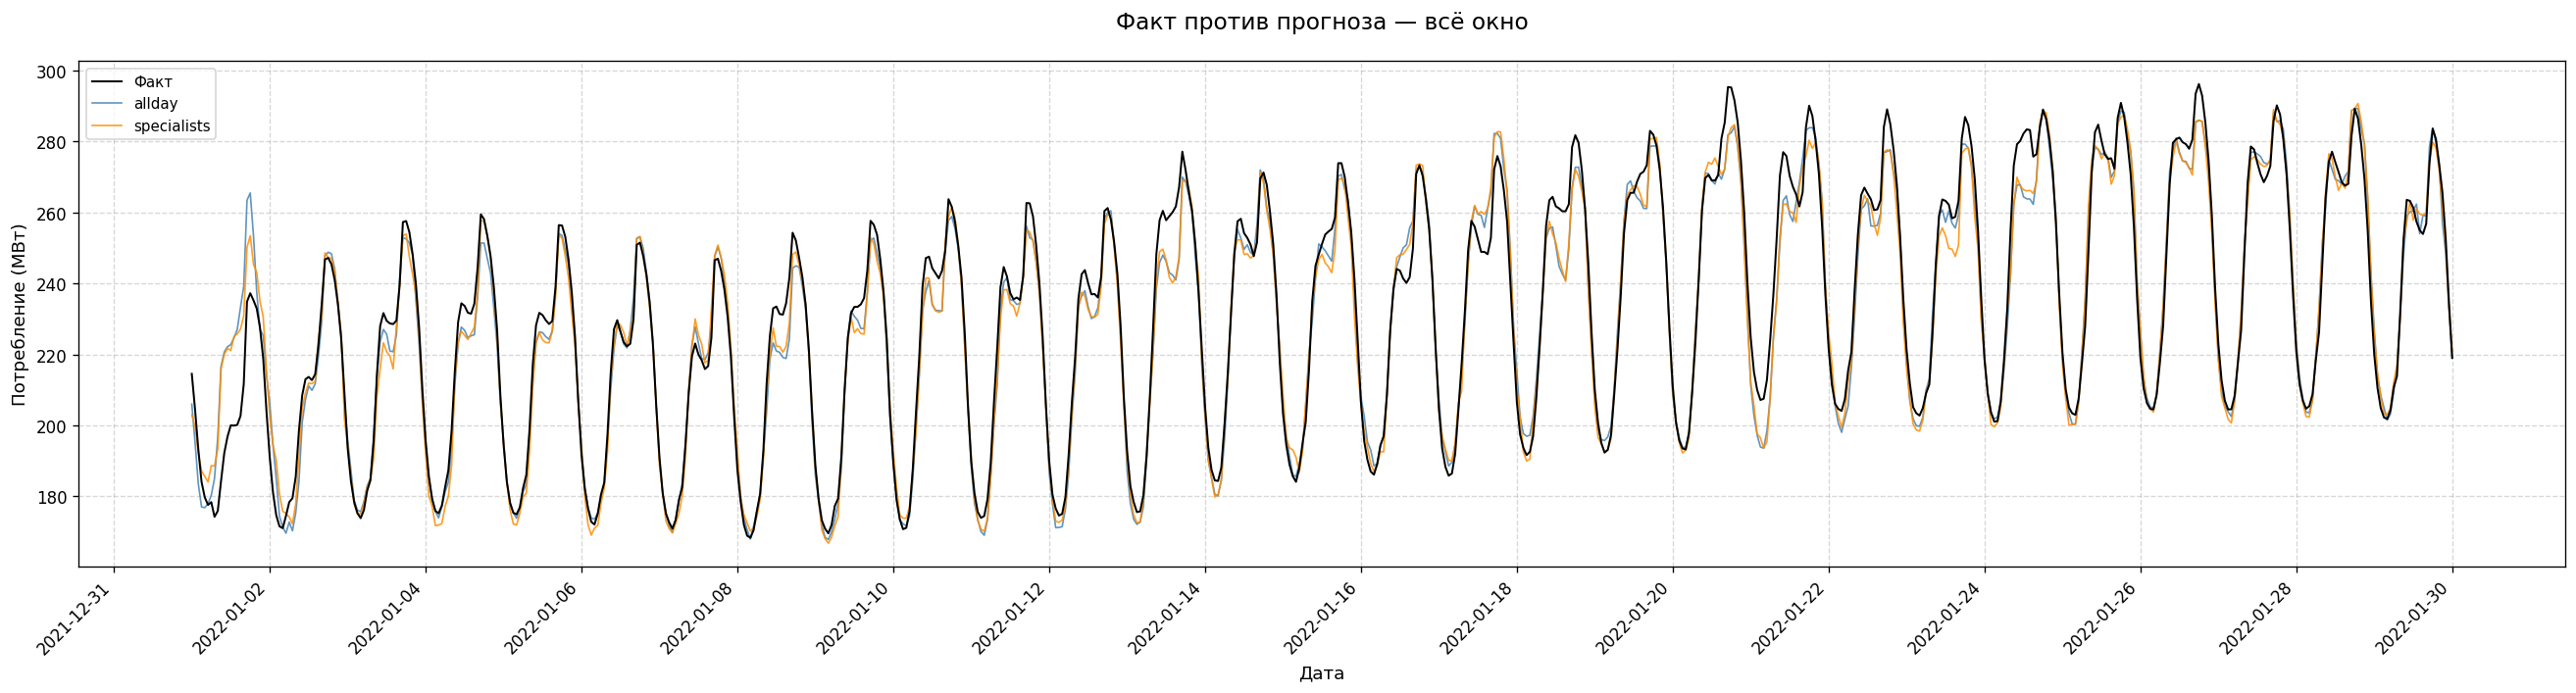

(<Figure size 2640x720 with 1 Axes>,
 <Axes: title={'center': 'Факт против прогноза — всё окно'}, xlabel='Дата', ylabel='Потребление (МВт)'>)

In [14]:
OUTPUT_DIR = ROOT_DIR / 'artefakts' / 'two_models_comparison'

ModelComparison.plot_forecast_by_day(
    result_df[DATE_COL], result_df['y_true'],
    {'allday': result_df['pred_allday'],
     'specialists': result_df['pred_specialists']},
    title='Факт против прогноза — всё окно',
    filename=str(OUTPUT_DIR / 'forecast_full_window.png'),
)

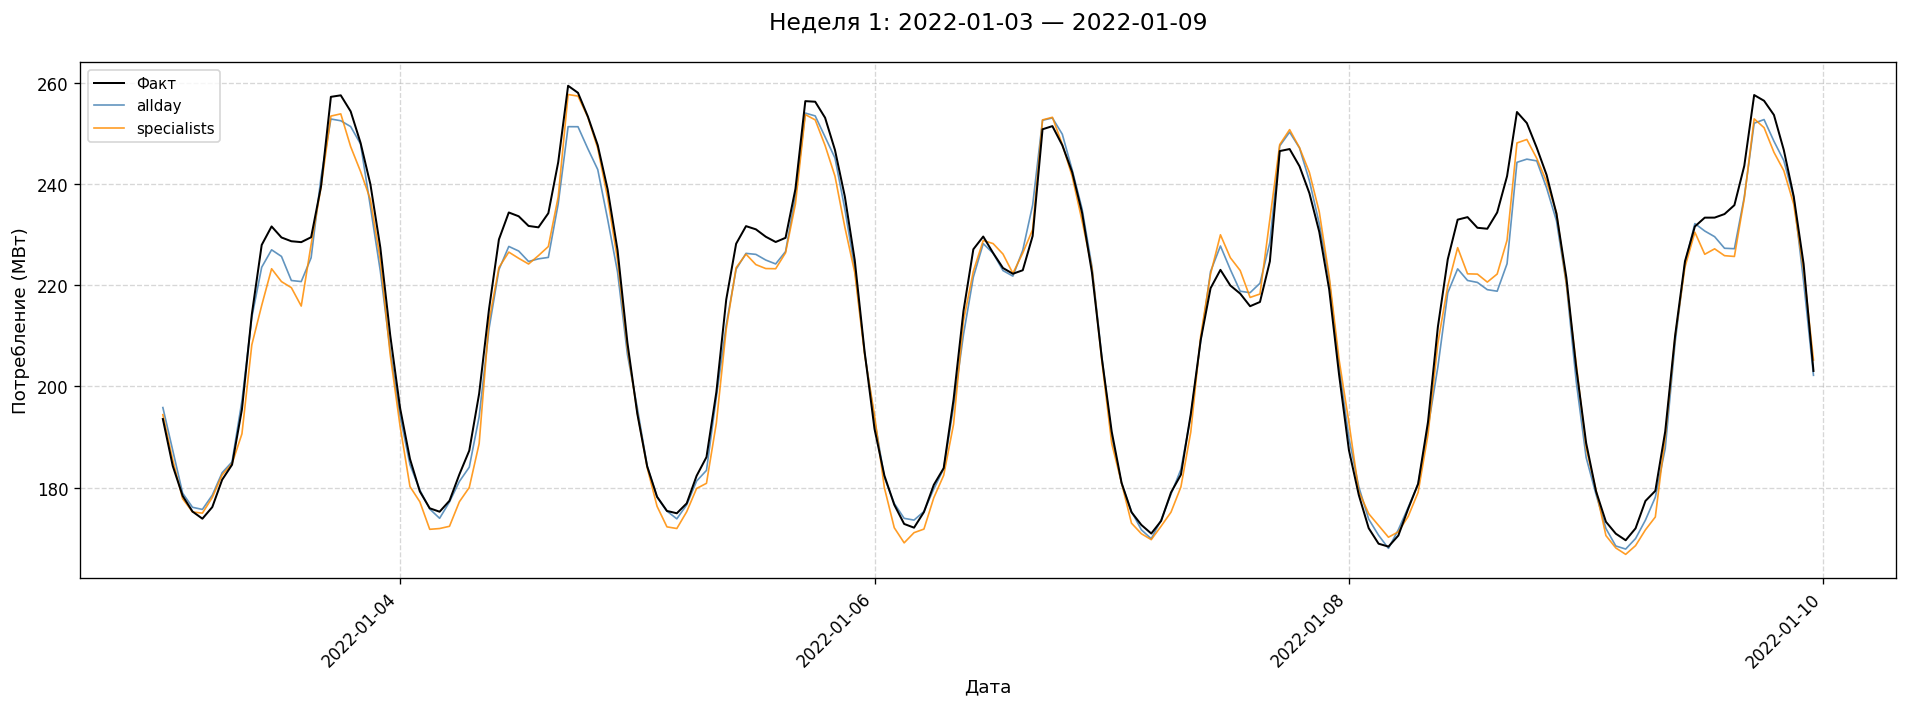

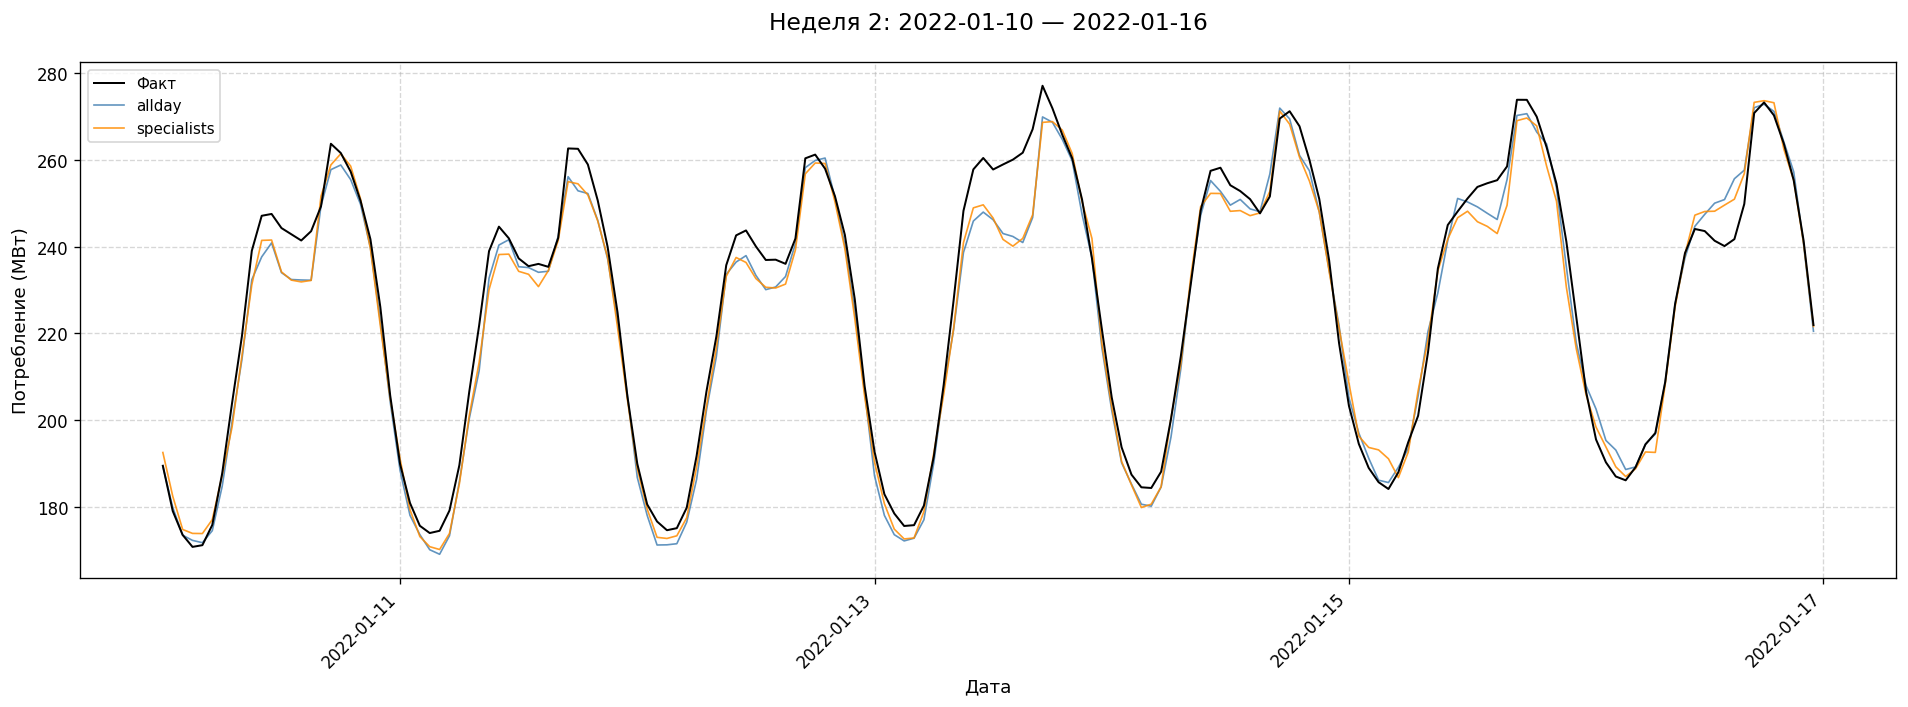

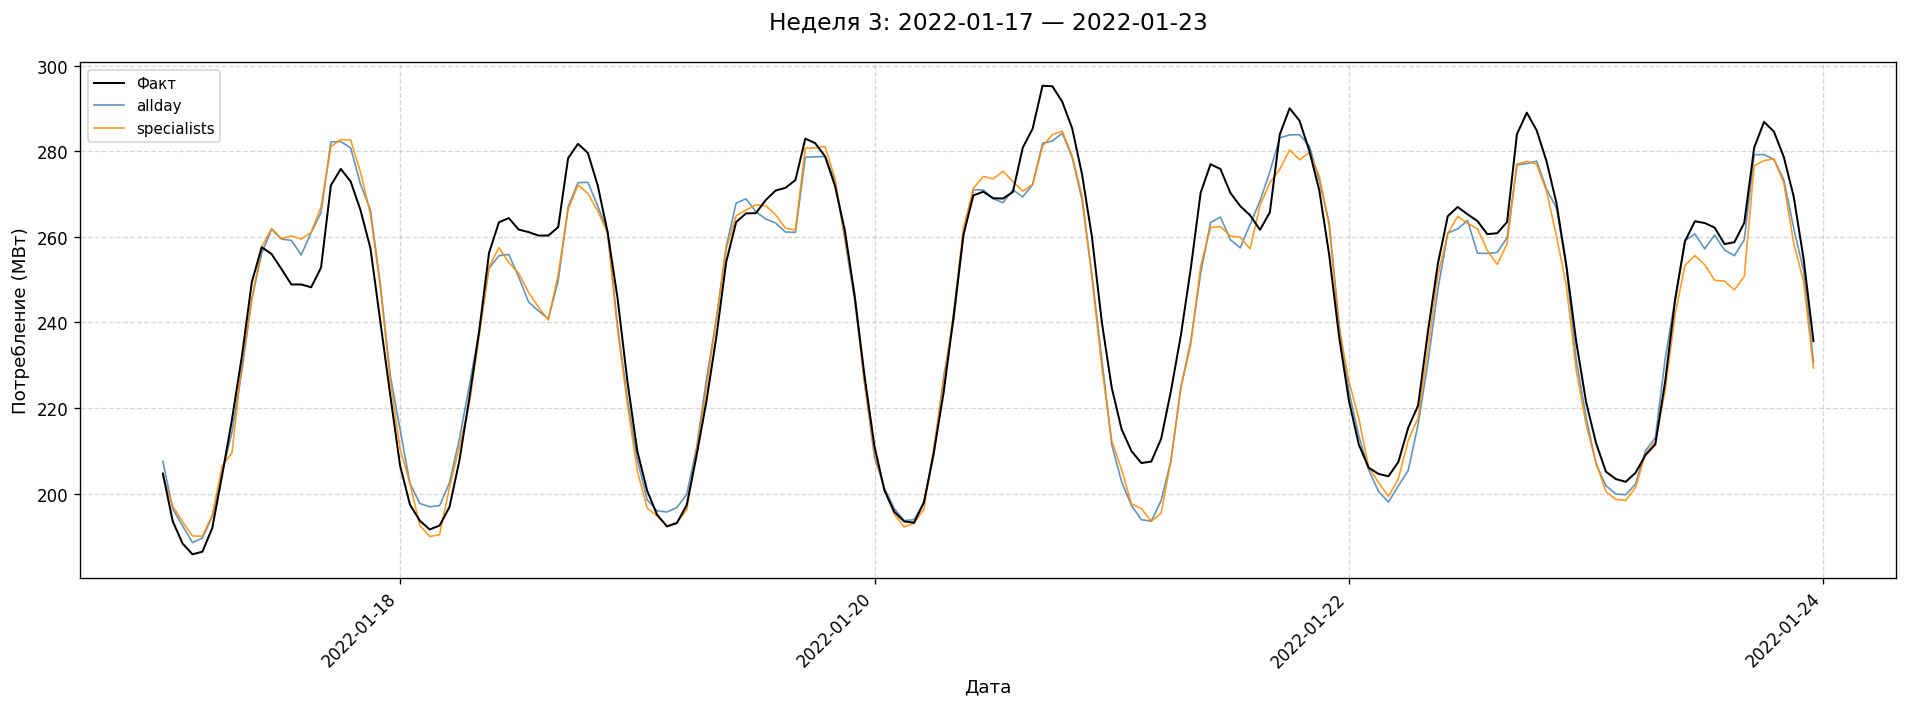

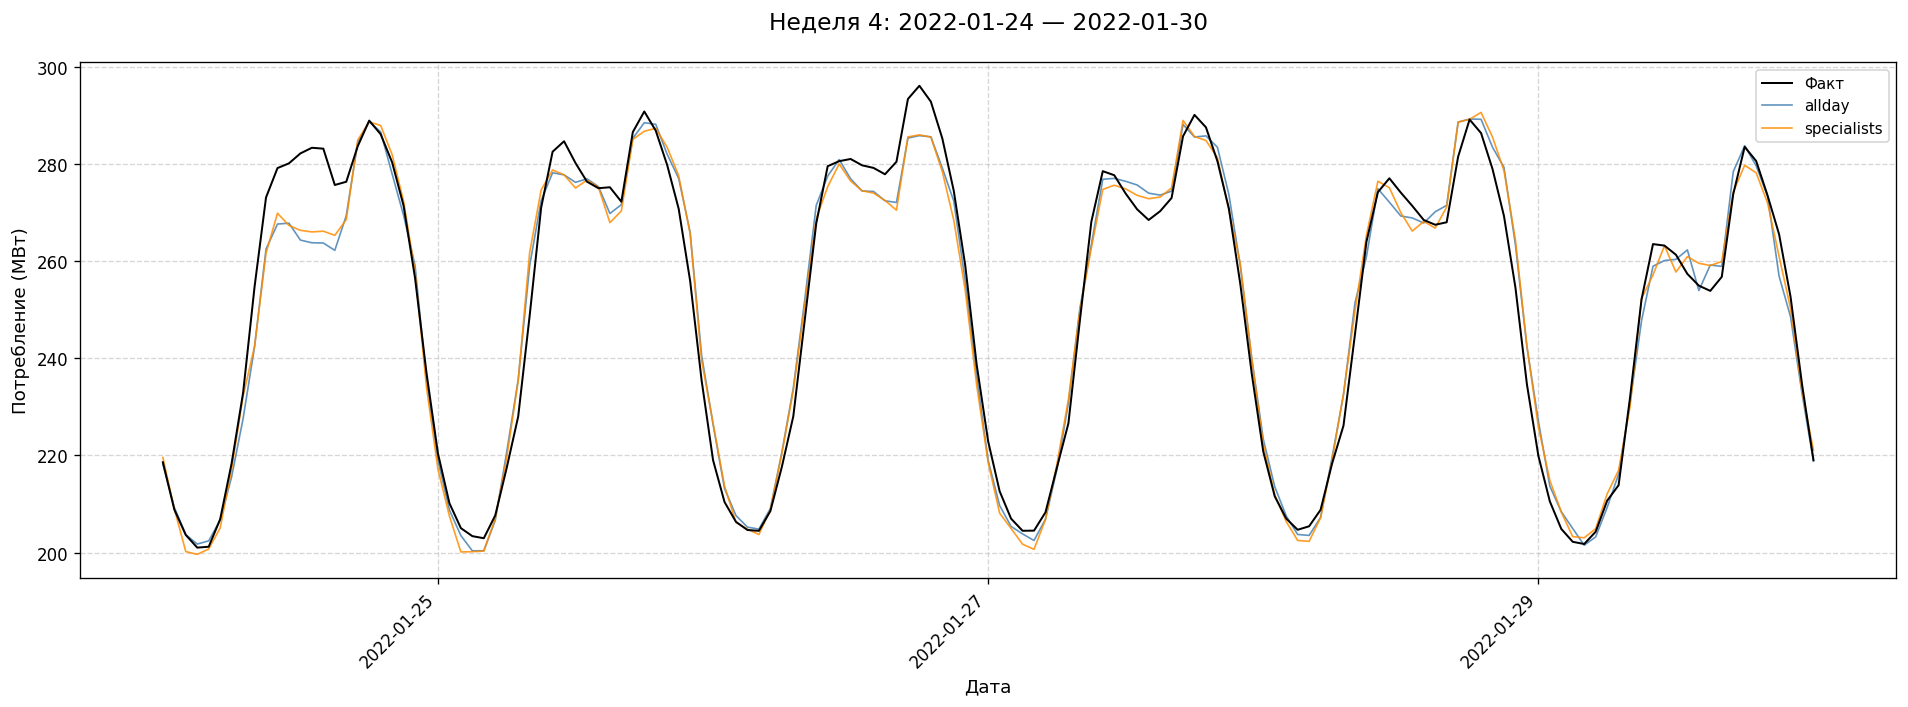

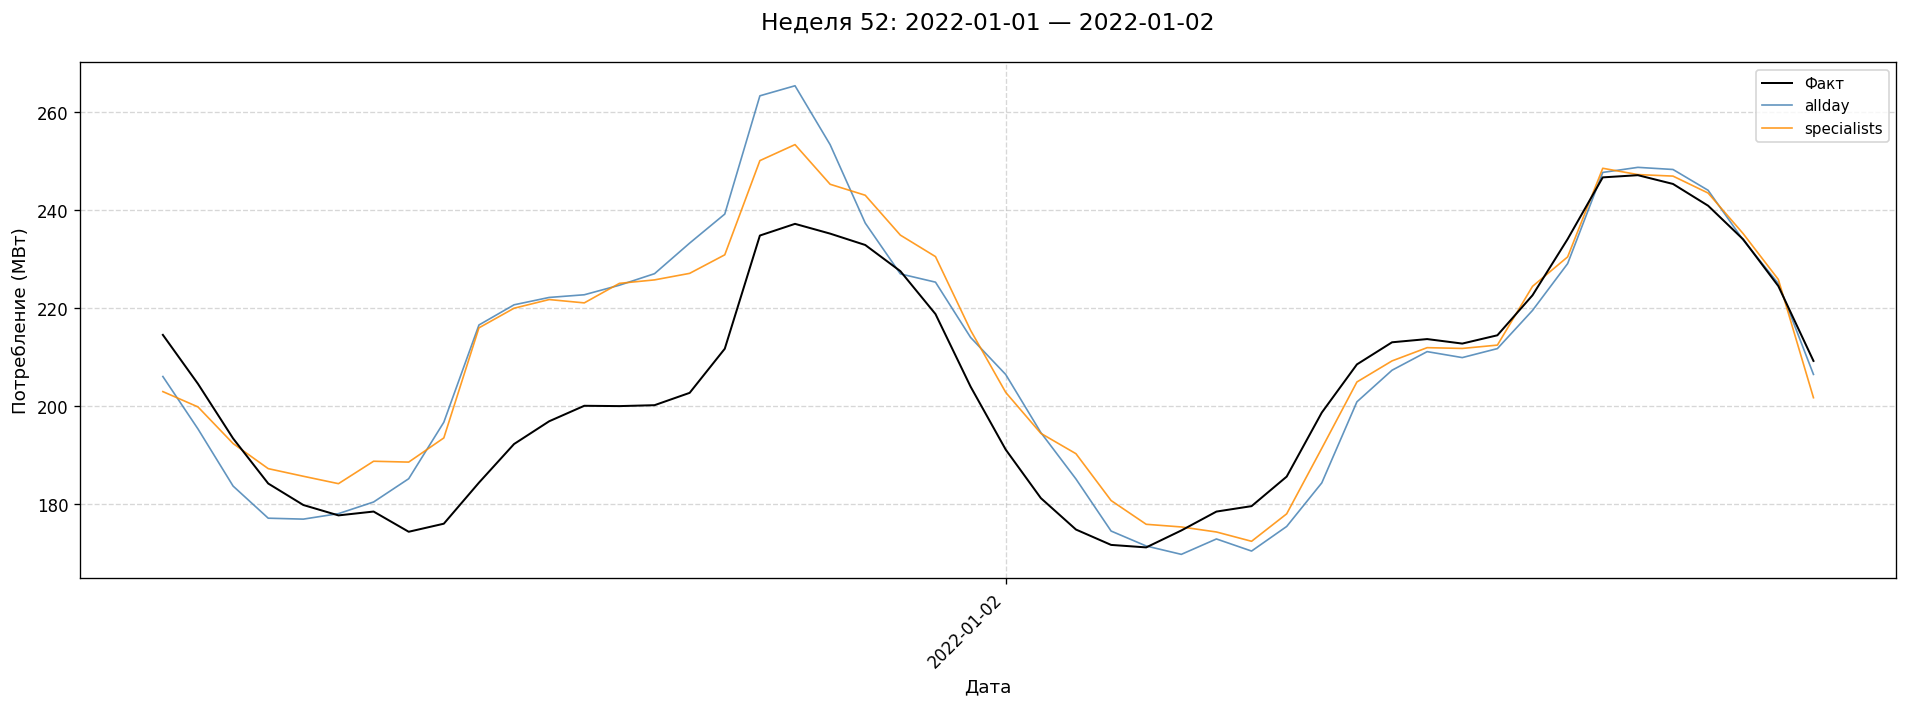

In [15]:
# Разбивка по неделям для детального просмотра суточных профилей.
result_df = result_df.sort_values(DATE_COL).reset_index(drop=True)
result_df['week'] = result_df[DATE_COL].dt.isocalendar().week
for week, chunk in result_df.groupby('week'):
    if len(chunk) < 24:
        continue
    d0, d1 = chunk[DATE_COL].min().date(), chunk[DATE_COL].max().date()
    ModelComparison.plot_forecast_by_day(
        chunk[DATE_COL], chunk['y_true'],
        {'allday': chunk['pred_allday'],
         'specialists': chunk['pred_specialists']},
        title=f'Неделя {int(week)}: {d0} — {d1}',
        figsize_width=16,
    )

## 11. Подневные ошибки (MAPE по дням)

Дополнительно к сводным метрикам полезно увидеть, в какие дни модели ошибаются сильнее. Считаем дневной MAPE для обеих моделей.

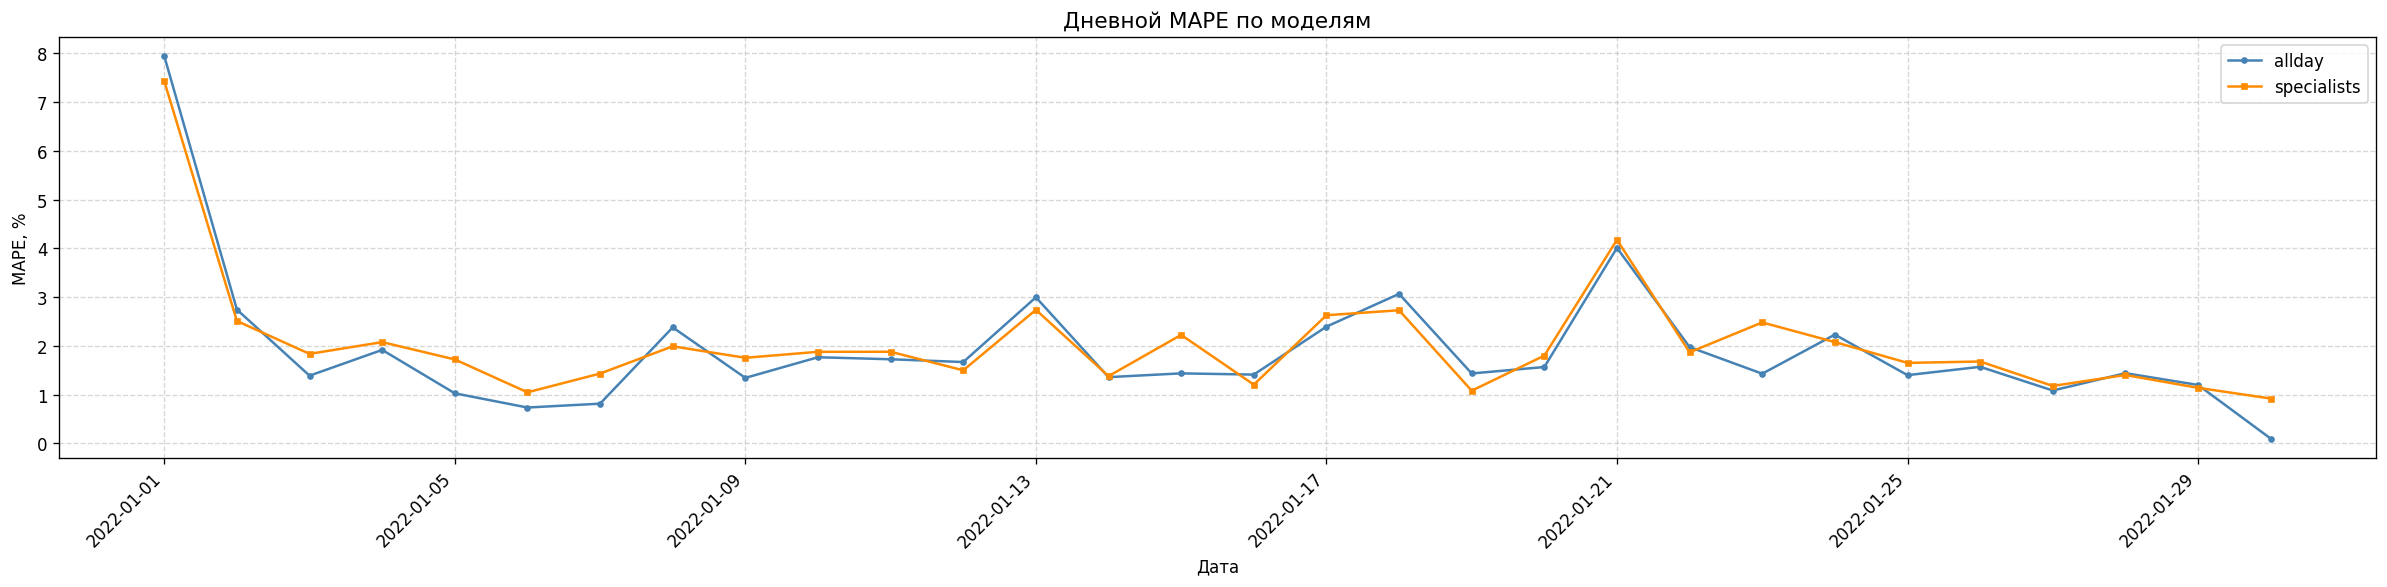

,date_only,mape_allday,mape_specialists,workday
0,2022-01-01,7.95,7.43,0.0
1,2022-01-02,2.75,2.51,0.0
2,2022-01-03,1.39,1.84,0.0
3,2022-01-04,1.92,2.08,0.0
4,2022-01-05,1.03,1.72,0.0
5,2022-01-06,0.74,1.05,0.0
6,2022-01-07,0.82,1.43,0.0
7,2022-01-08,2.38,1.99,0.0
8,2022-01-09,1.34,1.76,0.0
9,2022-01-10,1.77,1.88,1.0


In [16]:
result_df['date_only'] = result_df[DATE_COL].dt.date


def _daily_mape(group, pred_col):
    return ModelComparison.mape(group['y_true'], group[pred_col])


daily_err = result_df.groupby('date_only').apply(
    lambda g: pd.Series({
        'mape_allday': _daily_mape(g, 'pred_allday'),
        'mape_specialists': _daily_mape(g, 'pred_specialists'),
        'workday': int(g['workday'].iloc[0]),
    })
).reset_index()

fig, ax = plt.subplots(figsize=(20, 5))
ax.plot(pd.to_datetime(daily_err['date_only']), daily_err['mape_allday'],
        marker='o', ms=3, color='steelblue', label='allday')
ax.plot(pd.to_datetime(daily_err['date_only']), daily_err['mape_specialists'],
        marker='s', ms=3, color='darkorange', label='specialists')
ax.set_title('Дневной MAPE по моделям', fontsize=13)
ax.set_xlabel('Дата'); ax.set_ylabel('MAPE, %')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend()
plt.tight_layout()
plt.show()

daily_err.round(2).head(10)

## 12. Выводы

- Сравнили **универсальную** модель `allday` и **каскад специалистов** `workday`+`nonworkday` на одном прогнозном окне.
- Метрики (MAPE, WAPE, R²) и подневные графики позволяют выбрать архитектуру под бизнес-задачу планирования на день вперёд.
- Ноутбук самодостаточен: при отсутствии данных/моделей работает в демо-режиме и явно сообщает об этом (`USING_DEMO_DATA`).

**Дальнейшие шаги:** обучить модели через `project/src/avto_test_py/tune_allday_gpu.py` и `run_specialists_gpu.py`, затем перезапустить ноутбук на реальном датасете `project/data/dataset.xlsx`.